# Temperature pleasantness

How comfortable a place feels climate-wise, per 0.5° grid cell. Sourced from NASA POWER climatology (1991–2020): raw monthly air temperature (`T2M`) and relative humidity (`RH2M`). Ocean cells are masked via `is_land` from `grid.nc`.

The score is **preference-driven** along two independent axes — temperature *and* humidity — so climate-region presets can point at different places even when air temperatures agree. Cairo and Singapore both hit ~28 °C in summer, but a "hot dry" preset only lights up the desert margins and a "tropical humid" preset only lights up equatorial lowlands. Pipeline is two-stage:

1. **Stage A (expensive, run once):** fetch monthly T + RH, interpolate onto the atlas grid, cache to `processed/_temperature_monthly.nc` and `processed/_humidity_monthly.nc`.
2. **Stage B (cheap, rerun any time):** collapse the 12 + 12 monthly layers into an annual pleasantness score using four knobs (`ideal_temp`, `temp_tolerance`, `ideal_rh`, `rh_tolerance`). This is what `97_scoring.ipynb` consumes.

Changing preferences after the fact does not re-hit the API or re-interpolate — just call `compute_temperature_pleasantness(...)`.

In [1]:
import json

import numpy as np
import pandas as pd

from common import (
    RAW_DIR,
    PROCESSED_DIR,
    TEMP_PROFILES,
    load_grid,
    plot_map,
    save_variable,
)

from common import compute_temperature_pleasantness

VARIABLE = 'temperature_pleasantness'
variable_raw = RAW_DIR / VARIABLE
variable_raw.mkdir(parents=True, exist_ok=True)
temp_cache = PROCESSED_DIR / '_temperature_monthly.nc'
humidity_cache = PROCESSED_DIR / '_humidity_monthly.nc'

## 1. Fetch raw data

NASA POWER's climatology *regional* endpoint returns monthly + annual means on a 0.5° lat × 0.625° lon grid. The endpoint caps request area at ~10° × 10°, so we tile the globe into 648 tiles and cache each response as JSON. Same pattern as `13_sun_hours.ipynb`, but requesting two parameters (`T2M`, `RH2M`) instead of one.

First run: ~15–25 min (sequential requests). Re-runs: instant (cached).

In [2]:
from common import download_nasa_power_dataset
download_nasa_power_dataset(variable_raw, "T2M")
download_nasa_power_dataset(variable_raw, "RH2M")

POWER tiles:   0%|          | 0/648 [00:00<?, ?it/s]

POWER tiles: 100%|██████████| 648/648 [00:00<00:00, 137198.84it/s]

1297 tiles cached in /Users/lutz/Documents/alfatraining/projects/world-liveable-atlas/data/world-livable-atlas/raw/temperature_pleasantness


POWER tiles:   0%|          | 0/648 [00:00<?, ?it/s]

POWER tiles: 100%|██████████| 648/648 [00:00<00:00, 133283.10it/s]

1297 tiles cached in /Users/lutz/Documents/alfatraining/projects/world-liveable-atlas/data/world-livable-atlas/raw/temperature_pleasantness


## 2. Clean & assemble monthly climatology

Each tile JSON is a GeoJSON FeatureCollection. Every feature is a grid point with `geometry.coordinates = [lon, lat]` and `properties.parameter.{T2M,RH2M}.{JAN..DEC, ANN}`. We take all 12 monthly means for both variables independently — humidity is no longer folded into an apparent-temperature blend at this stage, so downstream presets can weight T and RH separately. NASA POWER uses `-999` as its fill value — skip those.

In [3]:
MONTHS = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN',
          'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']


def _load_monthly(param):
    """Load monthly means for one NASA POWER parameter across all cached tiles.

    Tiles overlap at their edges, so the same ``(lat, lon, month)`` cell can
    appear in multiple tile files. ``groupby(...).first()`` collapses those
    duplicates before pivoting into an xarray cube (xarray requires a unique
    MultiIndex).
    """
    records = []
    for tile_path in sorted(variable_raw.glob(f'tile_*_{param}.json')):
        doc = json.loads(tile_path.read_text())
        for feature in doc['features']:
            lon, lat = feature['geometry']['coordinates'][:2]
            values = feature['properties']['parameter'][param]
            for m_idx, m in enumerate(MONTHS, start=1):
                v = values.get(m)
                if v is None or v < -900:
                    continue
                records.append((lat, lon, m_idx, v))
    return (pd.DataFrame(records, columns=['lat', 'lon', 'month', param])
              .groupby(['lat', 'lon', 'month'], as_index=False)
              .first())


t_df = _load_monthly('T2M')
rh_df = _load_monthly('RH2M')
df = t_df.merge(rh_df, on=['lat', 'lon', 'month'], how='outer')
df

,lat,lon,month,T2M,RH2M
0,-90.0,-180.000,1,-28.77,92.52
1,-90.0,-180.000,2,-40.32,94.67
2,-90.0,-180.000,3,-51.85,95.50
3,-90.0,-180.000,4,-56.14,92.28
4,-90.0,-180.000,5,-56.84,91.56
...,...,...,...,...,...
2495227,90.0,179.375,8,-1.03,94.76
2495228,90.0,179.375,9,-6.66,96.82
2495229,90.0,179.375,10,-13.24,97.04
2495230,90.0,179.375,11,-19.31,95.82


## 3. Interpolate onto the atlas grid

Pivot the two variables to `(month, lat, lon)` xarray cubes, bilinear-interp onto the 0.5° atlas grid (same method as `13_sun_hours.ipynb`), mask ocean, and cache both to `processed/`. The underscore prefix signals these files are **not** scoring layers — they're the frozen climate substrate. Downstream code combines them via `compute_temperature_pleasantness`.

No apparent-temperature blend here: humidity is preserved as an independent axis so a climate-region preset can require *both* a temperature match and a humidity match (product of the two fits). This is what separates hot-dry (Cairo, Phoenix) from tropical humid (Singapore, Jakarta) despite similar summer air temperatures.

In [4]:
grid = load_grid()


def _interp(var_name, native_name):
    src = (df.set_index(['month', 'lat', 'lon'])[native_name]
             .to_xarray()
             .sortby(['month', 'lat', 'lon']))
    da = src.interp(lat=grid.lat, lon=grid.lon, method='linear')
    da = da.where(grid.is_land == 1).astype('float32')
    da.name = var_name
    return da


temperature_monthly = _interp('temperature_monthly', 'T2M')
temperature_monthly.attrs['units'] = '°C (NASA POWER T2M, monthly climatology 1991-2020)'
temperature_monthly.to_netcdf(temp_cache)
print(f'wrote {temp_cache}')

humidity_monthly = _interp('humidity_monthly', 'RH2M')
humidity_monthly.attrs['units'] = '% (NASA POWER RH2M, monthly climatology 1991-2020)'
humidity_monthly.to_netcdf(humidity_cache)
print(f'wrote {humidity_cache}')
temperature_monthly

wrote /Users/lutz/Documents/alfatraining/projects/world-liveable-atlas/data/world-livable-atlas/processed/_temperature_monthly.nc
wrote /Users/lutz/Documents/alfatraining/projects/world-liveable-atlas/data/world-livable-atlas/processed/_humidity_monthly.nc


<xarray.DataArray 'temperature_monthly' (month: 12, lat: 360, lon: 720)> Size: 12MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(12, 360, 720), dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Attributes:
    units:    °C (NASA POWER T2M, monthly climatology 1991-2020)

## 4. Sanity-check the climate signal

Four quick plots before we score anything:

- **Annual mean air temperature** — should look Köppen-ish, hot near the equator, cold at the poles.
- **Annual temperature range** (`max − min` across months) — should peak in continental interiors of the northern hemisphere (Siberia, central Canada) and stay low near coasts and equator.
- **Annual mean relative humidity** — high in the tropics and along coasts, low over deserts.
- **Annual humidity range** — Mediterranean/monsoon regions should stand out; steady tropical or steady arid regions should be flat.

<Axes: title={'center': 'annual mean air temperature (°C)'}, xlabel='longitude', ylabel='latitude'>

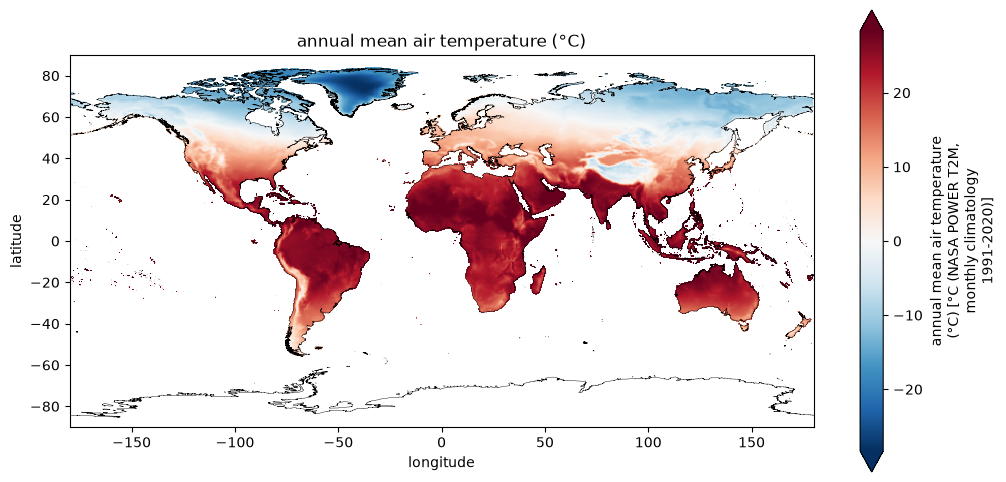

In [5]:
annual_mean_t = temperature_monthly.mean('month')
annual_mean_t.name = 'annual mean air temperature (°C)'
plot_map(annual_mean_t, cmap='RdBu_r', robust=True)

<Axes: title={'center': 'annual air-temperature range (°C)'}, xlabel='longitude', ylabel='latitude'>

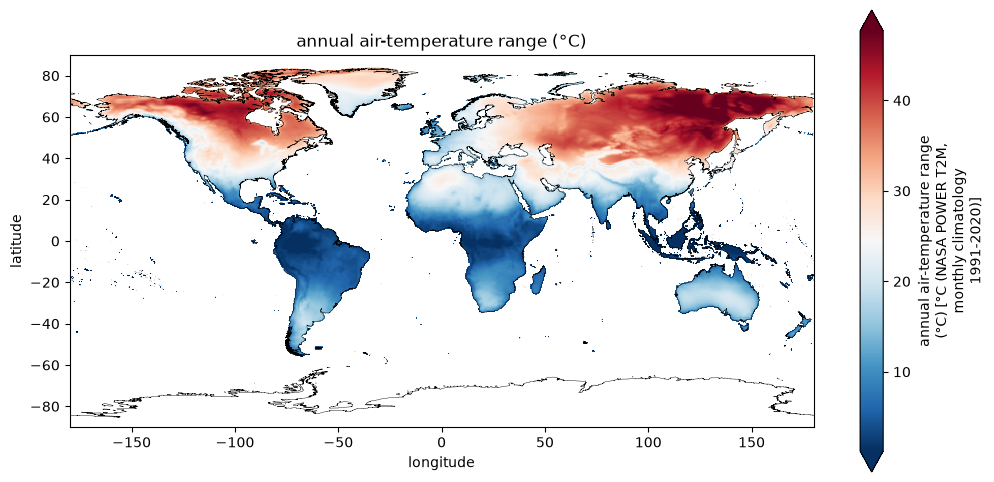

In [6]:
annual_range_t = temperature_monthly.max('month') - temperature_monthly.min('month')
annual_range_t.name = 'annual air-temperature range (°C)'
plot_map(annual_range_t, cmap='RdBu_r', robust=True)

<Axes: title={'center': 'annual mean relative humidity (%)'}, xlabel='longitude', ylabel='latitude'>

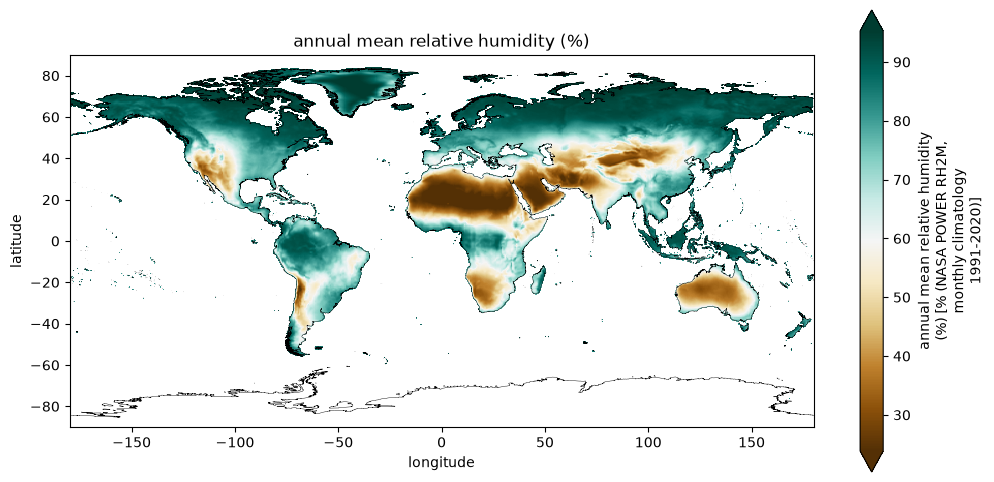

In [7]:
annual_mean_rh = humidity_monthly.mean('month')
annual_mean_rh.name = 'annual mean relative humidity (%)'
plot_map(annual_mean_rh, cmap='BrBG', robust=True)

<Axes: title={'center': 'annual humidity range (%)'}, xlabel='longitude', ylabel='latitude'>

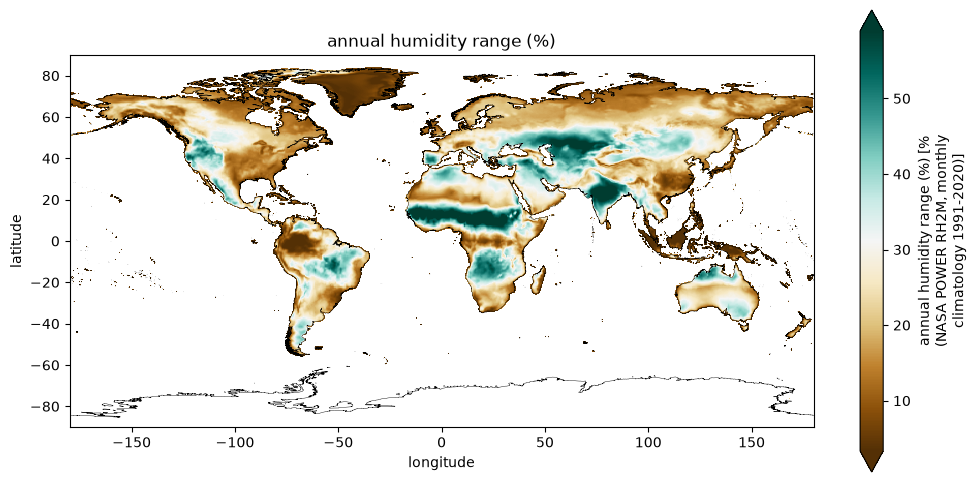

In [8]:
annual_range_rh = humidity_monthly.max('month') - humidity_monthly.min('month')
annual_range_rh.name = 'annual humidity range (%)'
plot_map(annual_range_rh, cmap='BrBG', robust=True)

## 5. Preference knobs → pleasantness

Two independent Laplace comfort functions — one on air temperature, one on relative humidity — multiplied together, so a cell only scores high when *both* axes match the preset:

```
t_comfort(month)  = exp(−|T(month)  − ideal_temp| / temp_tolerance)
rh_comfort(month) = exp(−|RH(month) − ideal_rh|   / rh_tolerance)

t_base       = mean of t_comfort  over 12 months
rh_base      = mean of rh_comfort over 12 months
expected_range = 2 · temp_tolerance
range_fit    = exp(−|actual_temp_range − expected_range| / expected_range)

pleasantness = (t_base · range_fit) · rh_base
```

Range 0–1, higher = better. **No hard cutoffs** — every cell scores above zero, smoothly decreasing with distance from the preset. `tolerance` is the distance at which the fit drops to `exp(-1) ≈ 0.37`; at 2·tolerance it's `0.14`, at 3·tolerance `0.05`, at 5·tolerance `0.007`. Compared to a Gaussian, this keeps a visible gradient even for narrow presets like Tropical or Hot Dry, at the cost of a cusped rather than rounded peak.

Range-fit is intrinsic to temperature only — the same preset that rewards Rome cannot accidentally reward Nairobi (flat mean but no seasons). Humidity has no range check — a stable-humid climate is not penalised for being stable.

**Presets (see `TEMP_PROFILES` in `common.py`):** climate-region presets that constrain both temperature and humidity.

- *Polar (−15 °C ±25, RH 80% ±25):* expected temp swing 50 °C — Norilsk, Iqaluit, Verkhoyansk. Extreme continental subarctic.
- *Cold Seasonal (−5 °C ±20, RH 75% ±25):* expected temp swing 40 °C — Anchorage, Moscow, Nuuk. Classic subarctic seasonality.
- *Mild Seasonal (10 °C ±15, RH 70% ±25):* expected temp swing 30 °C — Berlin, Toronto, Sapporo. Temperate NH.
- *Mediterranean (18 °C ±12, RH 55% ±20):* expected temp swing 24 °C, moderate humidity — Rome, Athens, LA, Cape Town, Perth.
- *Hot Dry (27 °C ±10, RH 25% ±15):* hot with a real seasonal swing, low humidity — Cairo, Riyadh, Phoenix.
- *Tropical Hot Humid (27 °C ±5, RH 82% ±12):* expected temp swing 10 °C, very humid — Singapore, Kuala Lumpur, Jakarta, Bangkok.

In [9]:
IDEAL_TEMP = 18.0     # °C — target air temperature
TEMP_TOLERANCE = 12.0  # °C — half-width of the temperature comfort band
IDEAL_RH = 60.0       # % — target relative humidity
RH_TOLERANCE = 25.0    # % — half-width of the humidity comfort band

pleasantness = compute_temperature_pleasantness(
    temp_source=temp_cache,
    humidity_source=humidity_cache,
    ideal_temp=IDEAL_TEMP,
    temp_tolerance=TEMP_TOLERANCE,
    ideal_rh=IDEAL_RH,
    rh_tolerance=RH_TOLERANCE,
)
pleasantness.name = VARIABLE
pleasantness.attrs['ideal_temp_C'] = IDEAL_TEMP
pleasantness.attrs['temp_tolerance_C'] = TEMP_TOLERANCE
pleasantness.attrs['ideal_rh_pct'] = IDEAL_RH
pleasantness.attrs['rh_tolerance_pct'] = RH_TOLERANCE
pleasantness

<xarray.DataArray 'temperature_pleasantness' (lat: 360, lon: 720)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(360, 720), dtype=float32)
Coordinates:
  * lat      (lat) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Attributes:
    ideal_temp_C:      18.0
    temp_tolerance_C:  12.0
    ideal_rh_pct:      60.0
    rh_tolerance_pct:  25.0

## 6. Plot pleasantness (one map per climate-region preset)

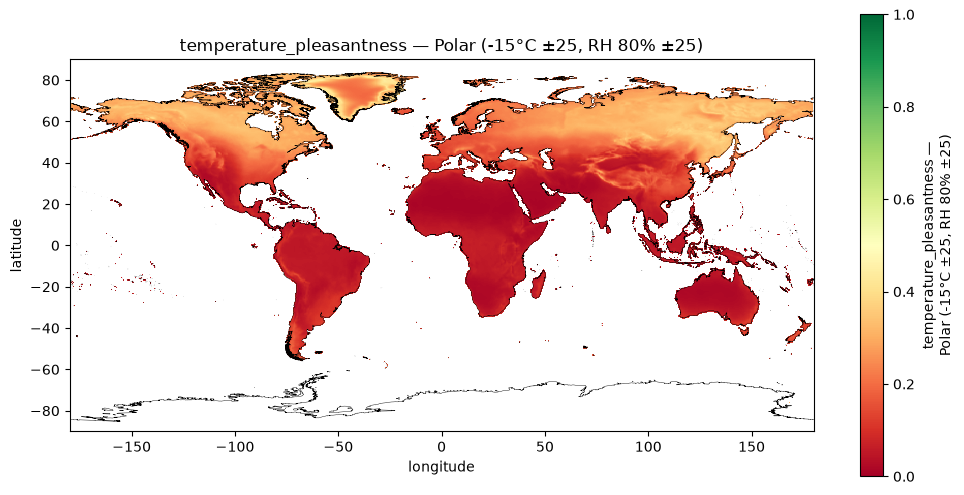

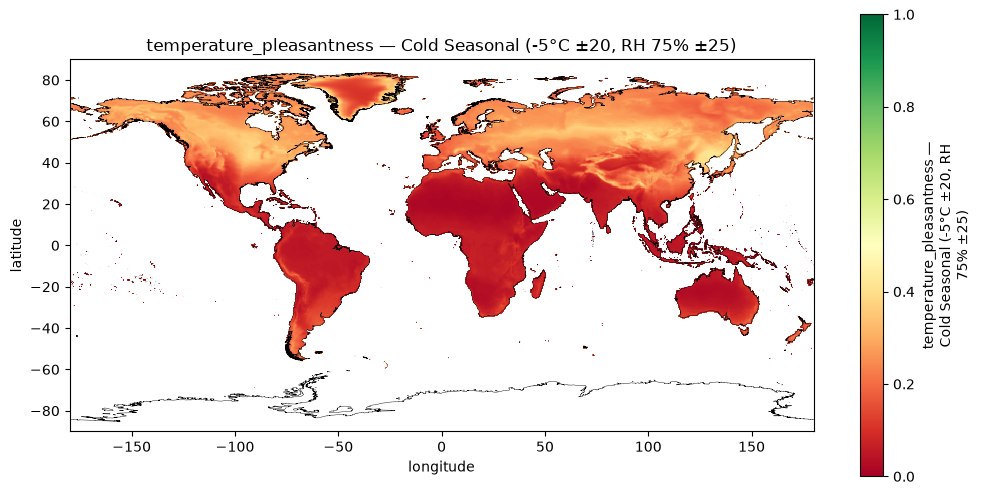

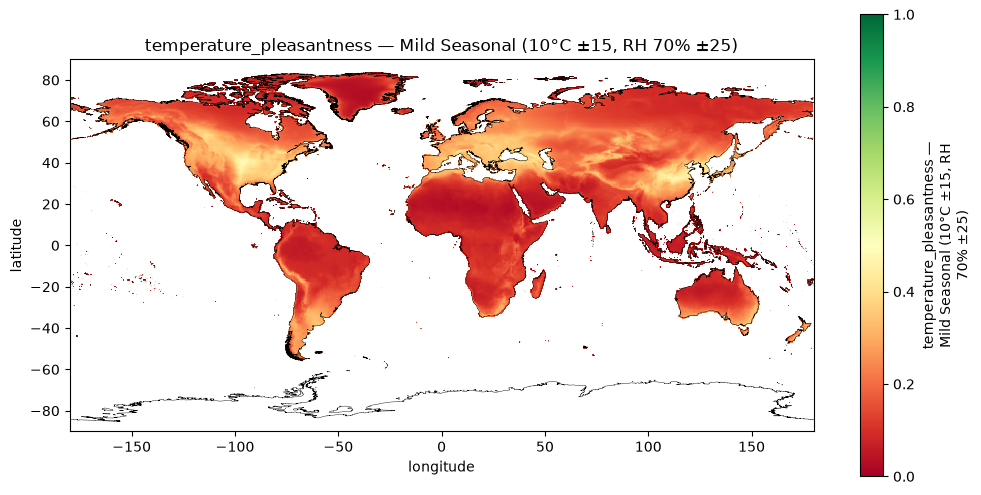

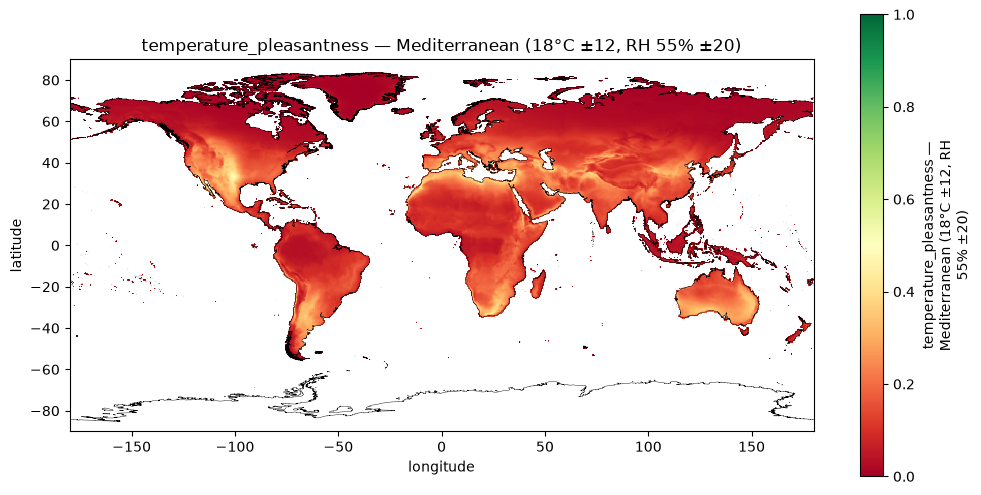

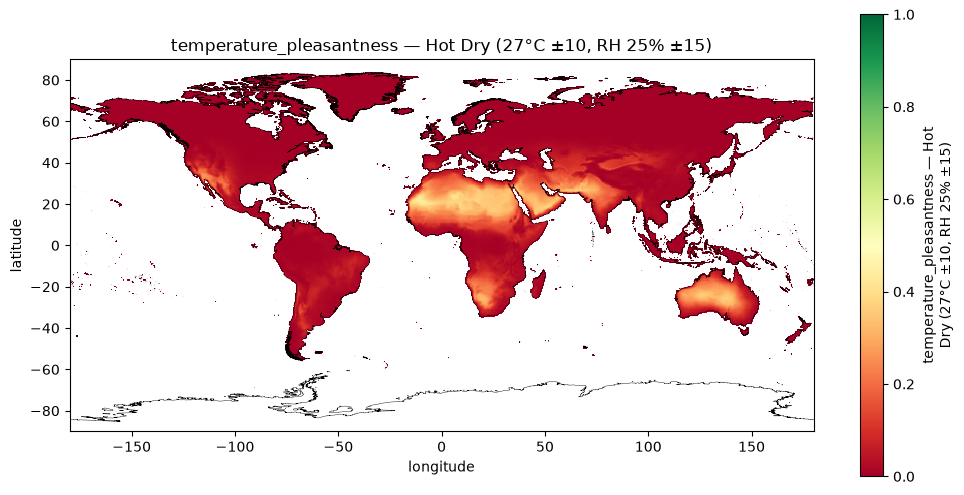

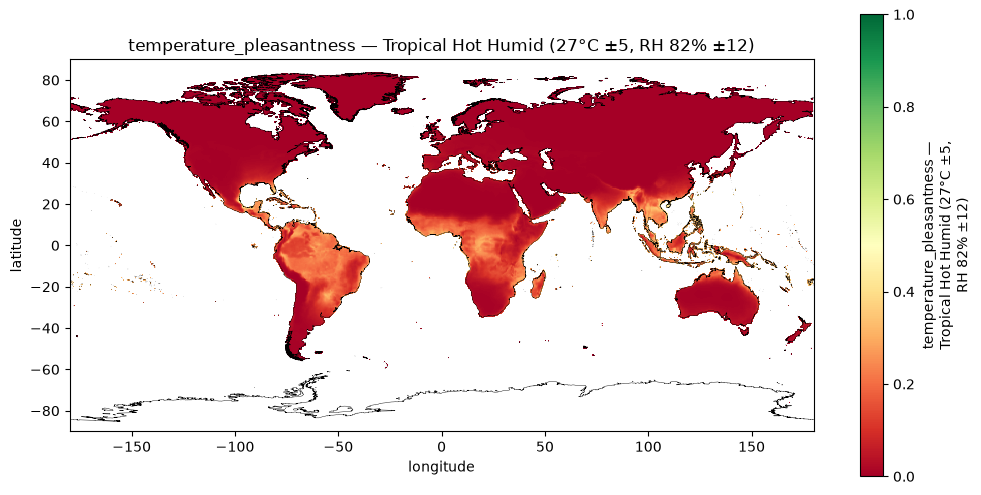

In [10]:
for label, (ideal_t, temp_tol, ideal_rh, rh_tol) in TEMP_PROFILES.items():
    alt = compute_temperature_pleasantness(
        temp_source=temp_cache,
        humidity_source=humidity_cache,
        ideal_temp=ideal_t,
        temp_tolerance=temp_tol,
        ideal_rh=ideal_rh,
        rh_tolerance=rh_tol,
    )
    alt.name = f'temperature_pleasantness — {label}'
    plot_map(alt, cmap='RdYlGn', vmin=0, vmax=1)

## 7. Save

Writes the default-preference score to `processed/temperature_pleasantness.nc` so `97_scoring.ipynb` picks it up. Re-scoring the atlas for a different preference is a one-liner: `compute_temperature_pleasantness(...).to_netcdf(...)`.

In [11]:
out = save_variable(pleasantness, VARIABLE)
print(f'wrote {out}')

wrote /Users/lutz/Documents/alfatraining/projects/world-liveable-atlas/data/world-livable-atlas/processed/temperature_pleasantness.nc
